In [22]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

from hubble_utils import *
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:


results_dir = Path("results/cosmo/mar9f_test")

rows = []

file_path = sorted(results_dir.iterdir())[0]

result = load_cosmo_results_hdf5(str(file_path))
print(f"Cosmo Result: ", result)
for model in ['FlatLambdaCDM', 'FlatwCDM', 'Flatw0waCDM']:
    N, z_i, z_f = result[model]["N"], result[model]['z_i'], result[model]['z_f']
    logZ = result[model]['logZ']
    print(f"For model {model}: {N=}, {z_i=}, {z_f=}")
    print("All results for the model: ", result[model].keys())
    print("\n")


Cosmo Result:  {'FlatLambdaCDM': {'H0': np.float64(73.47935765679885), 'H0_err': np.float64(0.9630383424994307), 'M0_agn': np.float64(-22.135943914065894), 'M0_agn_err': np.float64(0.06436044990708645), 'M0_sn': np.float64(-19.24286534830305), 'M0_sn_err': np.float64(0.028269807864148788), 'N': np.int64(2000), 'Om0': np.float64(0.33881552381199936), 'Om0_err': np.float64(0.01761183203554592), 'age': np.float64(12.408323254789732), 'age_err': np.float64(0.22729533894223916), 'alpha_agn': np.float64(4.639357067517125), 'alpha_agn_err': np.float64(0.29887435585600697), 'beta_agn': np.float64(-1.3557275383535128), 'beta_agn_err': np.float64(0.1265008189712601), 'logZ': np.float64(4156.610730056744), 'logZerr': np.float64(0.3167277202175046), 'log_f': np.float64(-0.10366745432357316), 'log_f_err': np.float64(0.03971428709985547), 'z_f': np.float64(1.5), 'z_i': np.float64(0.44)}, 'Flatw0waCDM': {'H0': np.float64(73.03550119706634), 'H0_err': np.float64(1.0603721675188567), 'M0_agn': np.float

In [20]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("results/cosmo/mar9f_test")

rows = []

for file_path in sorted(results_dir.iterdir()):
    if not file_path.is_file():
        continue

    result = load_cosmo_results_hdf5(str(file_path))

    for model in ["FlatLambdaCDM", "FlatwCDM", "Flatw0waCDM"]:
        rows.append({
            "cosmo_model": model,
            "logZ": result[model]["logZ"],
            "N": result[model]["N"],
            "z_f": result[model]["z_f"],
        })

df = pd.DataFrame(rows)
df = df.sort_values(["N", "z_f", "cosmo_model"]).reset_index(drop=True)

df.head()

,cosmo_model,logZ,N,z_f
0,FlatLambdaCDM,2231.197033,500,1.0
1,Flatw0waCDM,2226.711417,500,1.0
2,FlatwCDM,2229.005148,500,1.0
3,FlatLambdaCDM,2380.120154,500,1.5
4,Flatw0waCDM,2375.063570,500,1.5


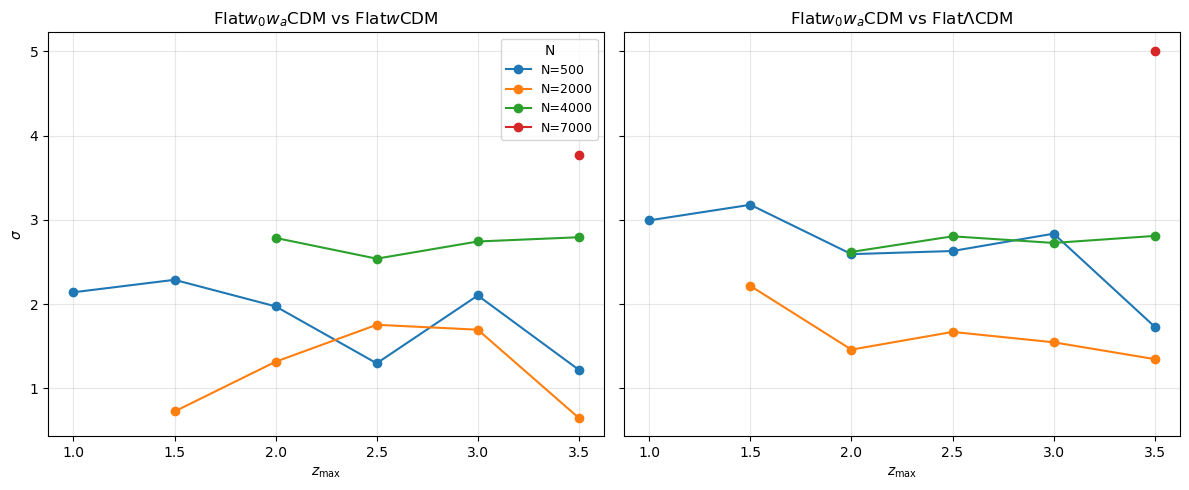

In [24]:
# Pivot so each row is one (N, z_f) with one column per cosmology
dfw = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZ").reset_index()

# Compute delta logZ and sigma
dfw["delta_w0wa_minus_w"] = dfw["Flatw0waCDM"] - dfw["FlatwCDM"]
dfw["delta_w0wa_minus_lcdm"] = dfw["Flatw0waCDM"] - dfw["FlatLambdaCDM"]

dfw["sigma_w0wa_vs_w"] = dfw["delta_w0wa_minus_w"].apply(odds_sigmas_from_delta)
dfw["sigma_w0wa_vs_lcdm"] = dfw["delta_w0wa_minus_lcdm"].apply(odds_sigmas_from_delta)

dfw = dfw.sort_values(["N", "z_f"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for N in sorted(dfw["N"].unique()):
    sub = dfw[dfw["N"] == N].sort_values("z_f")

    axes[0].plot(sub["z_f"], sub["sigma_w0wa_vs_w"], marker="o", label=f"N={N}")
    axes[1].plot(sub["z_f"], sub["sigma_w0wa_vs_lcdm"], marker="o", label=f"N={N}")

axes[0].set_title(r"Flat$w_0w_a$CDM vs Flat$w$CDM")
axes[1].set_title(r"Flat$w_0w_a$CDM vs Flat$\Lambda$CDM")

axes[0].set_xlabel(r"$z_{\max}$")
axes[1].set_xlabel(r"$z_{\max}$")
axes[0].set_ylabel(r"$\sigma$")

axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)

axes[0].legend(title="N", fontsize=9)

plt.tight_layout()
plt.show()